In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import DLinearModel
import numpy as np
from typing import Optional, Dict, Union, Literal
from pathlib import Path
from chronos import BaseChronosPipeline
import torch

/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


In [2]:
# # Use only 1 GPU if available
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["HF_HUB_DISABLE_XET"] = "1"
# os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # Disable progress bars

# from chronos import BaseChronosPipeline, Chronos2Pipeline
# from datetime import datetime
# import torch
# import os
# from datetime import datetime
# from ts_toolkit.utils.chronos_tune_input_generator import chronos_input_generator


# torch.cuda.empty_cache()
# # Load the Chronos-2 pipeline
# # GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
# pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

In [3]:
# # Load COVID CSV and analyze peak cross-correlation (Upstream_Montague vs Downstream_Trenton)
# REPO_ROOT = os.getenv("REPO_ROOT", ".")
# covid_path = os.path.join(REPO_ROOT, "data", "real", "covid.csv")
# df = pd.read_csv(covid_path)


# # Lag range: e.g. ±168 for hourly (1 week) or adapt to series length
# max_lag = 8
# lags = range(-max_lag, max_lag + 1)

# corrs = [df["COVID-19 hospital admissions"].shift(lag).corr(df["COVID-19 deaths"]) for lag in lags]
# # Find the peak lag
# peak_lag = lags[corrs.index(max(corrs))]
# print(f"Peak Correlation is at lag: {peak_lag} samples")

In [2]:
def calculate_metrics(
    forecast: np.ndarray,
    y_test: np.ndarray,
    y_train: Optional[np.ndarray] = None,
    seasonal_frequency: Optional[int] = None,
    seasonal_error: Optional[np.ndarray] = None,
    quantile_forecasts: Optional[Dict[str, np.ndarray]] = None,
    alpha: float = 0.05,
) -> Dict[str, float]:
    """
    Calculate forecasting metrics comparing forecast and y_test, following GluonTS methods.
    """
    forecast = np.asarray(forecast)
    y_test = np.asarray(y_test)
    
    if forecast.ndim == 1:
        forecast = forecast.reshape(1, -1)
    if y_test.ndim == 1:
        y_test = y_test.reshape(1, -1)
    
    if forecast.shape != y_test.shape:
        raise ValueError(f"forecast shape {forecast.shape} must match y_test shape {y_test.shape}")
    
    # Calculate input_mean (mean of y_train/context) for MAR and MBR
    input_mean = None
    if y_train is not None:
        y_train = np.asarray(y_train)
        if y_train.ndim == 1:
            y_train = y_train.reshape(1, -1)
        # Calculate mean of y_train (context)
        input_mean = np.mean(y_train, axis=1, keepdims=True)
        # Broadcast to match forecast/y_test shape
        if input_mean.shape[1] == 1:
            input_mean = np.repeat(input_mean, y_test.shape[1], axis=1)
    
    # Calculate seasonal_error if y_train and seasonal_frequency are provided
    if seasonal_error is None and y_train is not None and seasonal_frequency is not None:
        if y_train.ndim == 1:
            y_train = y_train.reshape(1, -1)
        if y_train.shape[0] != y_test.shape[0]:
            raise ValueError(f"y_train shape[0] {y_train.shape[0]} must match y_test shape[0] {y_test.shape[0]}")
        
        seasonal_errors = []
        for i in range(y_train.shape[0]):
            series = y_train[i]
            if len(series) < seasonal_frequency:
                raise ValueError(f"y_train series length {len(series)} must be >= seasonal_frequency {seasonal_frequency}")
            seasonal_diff = np.abs(series[seasonal_frequency:] - series[:-seasonal_frequency])
            seasonal_errors.append(np.mean(seasonal_diff))
        
        seasonal_error_value = np.mean(seasonal_errors)
    elif seasonal_error is not None:
        seasonal_error = np.asarray(seasonal_error)
        if seasonal_error.shape != forecast.shape:
            raise ValueError(f"seasonal_error shape {seasonal_error.shape} must match forecast shape {forecast.shape}")
        seasonal_error_value = np.mean(np.abs(seasonal_error))
    else:
        seasonal_error_value = None
    
    error = y_test - forecast
    absolute_error = np.abs(error)
    squared_error = error ** 2
    
    results = {}
    results["MAE"] = np.mean(absolute_error)
    results["MSE"] = np.mean(squared_error)
    results["RMSE"] = np.sqrt(results["MSE"])
    
    abs_label = np.abs(y_test)
    percentage_error = absolute_error / abs_label
    results["MAPE"] = np.mean(percentage_error)
    
    abs_forecast = np.abs(forecast)
    denominator = abs_label + abs_forecast
    smape_values = 2 * absolute_error / denominator
    results["SMAPE"] = np.mean(smape_values)
    
    sum_absolute_error = np.sum(absolute_error)
    sum_absolute_label = np.sum(abs_label)
    results["ND"] = sum_absolute_error / sum_absolute_label
    
    mean_absolute_label = np.mean(abs_label)
    results["NRMSE"] = results["RMSE"] / mean_absolute_label
    
    if seasonal_error_value is not None and seasonal_error_value > 0:
        results["MASE"] = results["MAE"] / seasonal_error_value
    else:
        results["MASE"] = np.nan
    
    # MAR: Mean Attraction Ratio
    # MAR = mean(|y_test - input_mean|) / mean(|forecast - input_mean|)
    # where input_mean = mean(y_train) 
    if input_mean is not None:
        deviation_label = np.abs(y_test - input_mean)
        deviation_forecast = np.abs(forecast - input_mean)
        mean_deviation_label = np.mean(deviation_label)
        mean_deviation_forecast = np.mean(deviation_forecast)
        if mean_deviation_forecast > 0:
            results["MAR"] = mean_deviation_label / mean_deviation_forecast
        else:
            results["MAR"] = np.nan
    else:
        results["MAR"] = np.nan
    
    # MBR: Mean Bias Ratio
    # MBR = mean(sign(y_test - input_mean) == sign(y_test - forecast))
    # where input_mean = mean(y_train)
    if input_mean is not None:
        sign_label_minus_mean = np.sign(y_test - input_mean)
        sign_label_minus_forecast = np.sign(y_test - forecast)
        bias_towards_mean = (sign_label_minus_mean == sign_label_minus_forecast)
        results["MBR"] = np.mean(bias_towards_mean)
    else:
        results["MBR"] = np.nan
    
    if quantile_forecasts is not None and seasonal_error_value is not None and seasonal_error_value > 0:
        lower_q = str(alpha / 2)
        upper_q = str(1 - alpha / 2)
        if lower_q in quantile_forecasts and upper_q in quantile_forecasts:
            lower_quantile = np.asarray(quantile_forecasts[lower_q])
            upper_quantile = np.asarray(quantile_forecasts[upper_q])
            if lower_quantile.shape != forecast.shape or upper_quantile.shape != forecast.shape:
                raise ValueError(f"Quantile forecast shapes must match forecast shape {forecast.shape}")
            interval_width = upper_quantile - lower_quantile
            lower_penalty = np.maximum(0, lower_quantile - y_test)
            upper_penalty = np.maximum(0, y_test - upper_quantile)
            interval_score = interval_width + (2.0 / alpha) * (lower_penalty + upper_penalty)
            scaled_interval_score = interval_score / seasonal_error_value
            results["MSIS"] = np.mean(scaled_interval_score)
        else:
            results["MSIS"] = np.nan
    else:
        results["MSIS"] = np.nan
    
    return results

In [3]:
def run_forecasting_experiment(
    model_type: str,
    dataset_name: str,
    y_column: str,
    x_column: Optional[str] = None,
    forecast_horizon: int = 30,
    use_covariate: bool = True,
    seasonal_frequency: Optional[int] = None,
    data_path: Optional[str] = None,
    df: Optional[pd.DataFrame] = None,
    plot: bool = True,
    calculate_metrics_flag: bool = True,
    lookback_window: Optional[int] = None,
    n_epochs: int = 50,
    random_state: int = 42,
    chronos_repo_id: str = "amazon/chronos-2",
    hpo_flag: bool = False,
    grid_search_list: Optional[list] = None,
) -> Dict:
    """
    Run a forecasting experiment with Chronos2 or DLinear model.
    """
    # Load data: use provided df or load from path
    if df is not None:
        pass  
    else:
        if data_path is None:
            REPO_ROOT = os.getenv("REPO_ROOT", ".")
            possible_paths = [
                os.path.join(REPO_ROOT, "data", "real", f"{dataset_name}_w_leak.csv"),
                os.path.join(REPO_ROOT, "data", "real", f"{dataset_name}.csv"),
            ]
            for path in possible_paths:
                if os.path.exists(path):
                    data_path = path
                    break
            if data_path is None:
                raise FileNotFoundError(f"Could not find data file for {dataset_name}")
        print(f"Loading data from {data_path}")
        df = pd.read_csv(data_path)

    # Time index for x-axis
    if isinstance(df.index, pd.DatetimeIndex):
        time_index = df.index
    else:
        date_col = next((c for c in df.columns if "date" in c.lower() or "time" in c.lower()), None)
        if date_col is not None:
            time_index = pd.to_datetime(df[date_col].values)
        else:
            time_index = pd.date_range(start="2000-01-01", periods=len(df), freq="D")

    # Extract target and covariate
    y = df[y_column].values
    X = df[[x_column]].values if use_covariate and x_column is not None else None
    
    # Train-test split
    test_size = max(forecast_horizon, int(0.2 * len(y)))
    test_size = (test_size // forecast_horizon) * forecast_horizon
    train_end_global = len(y) - test_size
    n_folds = test_size // forecast_horizon

    print(f"Training: up to {train_end_global} samples. Test: last {test_size}, {n_folds} folds.")

    forecast_list, y_test_list, conf_int_list = [], [], []
    model = None

    # Load Chronos2 pipeline locally on CPU
    if model_type.lower() == "chronos2":
        print(f"Loading Chronos-2 from local cache on CPU...")
        # local_files_only=True ensures we don't hit the NVML/Network error again
        _chronos_pipeline = BaseChronosPipeline.from_pretrained(
            chronos_repo_id, 
            device_map="cpu", 
            torch_dtype=torch.float32,
            local_files_only=True 
        )

    # hpo on lookback if dlinear
    if model_type.lower() == "dlinear" and hpo_flag:
        grid = grid_search_list if grid_search_list else [forecast_horizon, forecast_horizon*2, forecast_horizon*4]
        
        # We use the data BEFORE train_end_global for HPO
        # Let's take the last 10% of the training block as our HPO "Test" area
        hpo_total_size = int(0.1 * train_end_global)
        hpo_total_size = (hpo_total_size // forecast_horizon) * forecast_horizon
        hpo_train_start_global = train_end_global - hpo_total_size
        hpo_n_folds = hpo_total_size // forecast_horizon
        
        best_avg_mse = float('inf')
        best_window = lookback_window if lookback_window else forecast_horizon

        from darts import TimeSeries
        from darts.models import DLinearModel

        print(f"Starting HPO Cross-Validation ({hpo_n_folds} folds) for DLinear...")

        for window in grid:
            print("current hyper value: ", window)
            fold_mses = []
            for h_fold in range(hpo_n_folds):
                h_train_end = hpo_train_start_global + h_fold * forecast_horizon
                
                # Split for this HPO fold
                y_h_train = y[:h_train_end].astype(np.float32)
                y_h_val = y[h_train_end : h_train_end + forecast_horizon].astype(np.float32)
                
                y_h_train_ts = TimeSeries.from_values(y_h_train)
                
                temp_model = DLinearModel(
                    input_chunk_length=window,
                    output_chunk_length=forecast_horizon,
                    n_epochs=n_epochs,
                    random_state=random_state,
                    pl_trainer_kwargs={"accelerator": "cpu"}
                )
                
                # Handle covariates in HPO if enabled
                if use_covariate and X is not None:
                    X_h_train_ts = TimeSeries.from_values(X[:h_train_end].astype(np.float32))
                    temp_model.fit(y_h_train_ts, past_covariates=X_h_train_ts, verbose=False)
                    pred_ts = temp_model.predict(n=forecast_horizon, series=y_h_train_ts, past_covariates=X_h_train_ts)
                else:
                    temp_model.fit(y_h_train_ts, verbose=False)
                    pred_ts = temp_model.predict(n=forecast_horizon, series=y_h_train_ts)
                
                mse = np.mean((pred_ts.values().flatten() - y_h_val)**2)
                fold_mses.append(mse)
            
            avg_mse = np.mean(fold_mses)
            print(f"  Window {window}: Avg CV MSE = {avg_mse:.4f}")
            
            if avg_mse < best_avg_mse:
                best_avg_mse = avg_mse
                best_window = window
        
        print(f"HPO Complete. Best lookback_window: {best_window}")
        lookback_window = best_window

    for fold in range(n_folds):
        train_end = train_end_global + fold * forecast_horizon
        y_train = y[:train_end]
        y_test_fold = y[train_end : train_end + forecast_horizon]
        
        X_train = X[:train_end] if X is not None else None

        print(f"  Fold {fold + 1}/{n_folds}: train length={len(y_train)}")

        if model_type.lower() == "chronos2":
            # 1. Ensure time_train is a proper DatetimeIndex with a fixed frequency
            time_train = time_index[:train_end]
                
            context_df = pd.DataFrame({
                "item_id": "0",
                "timestamp": time_train,
                "target": y_train.astype(np.float32),
            })
            if use_covariate and X_train is not None:
                context_df["past_covariate"] = X_train.flatten().astype(np.float32)
            
            pred_df = _chronos_pipeline.predict_df(
                context_df,
                prediction_length=forecast_horizon,
                id_column="item_id",
                timestamp_column="timestamp",
                target="target",
            )
            pf = pred_df["predictions"]
            forecast_fold = np.array(pf).flatten()
            forecast_list.append(forecast_fold)
            if "0.1" in pred_df.columns and "0.9" in pred_df.columns:
                conf_int_list.append(pred_df[["0.1", "0.9"]].values)

        elif model_type.lower() == "dlinear":
            from darts import TimeSeries
            from darts.models import DLinearModel
            if lookback_window is None:
                lookback_window = forecast_horizon
            
            y_train_ts = TimeSeries.from_values(y_train)
            model = DLinearModel(
                input_chunk_length=lookback_window,
                output_chunk_length=forecast_horizon,
                n_epochs=n_epochs,
                random_state=random_state,
                pl_trainer_kwargs={"accelerator": "cpu"} # Ensure DLinear also uses CPU
            )
            
            if use_covariate and X_train is not None:
                X_train_ts = TimeSeries.from_values(X_train)
                model.fit(y_train_ts, past_covariates=X_train_ts, verbose=False)
                forecast_ts = model.predict(n=forecast_horizon, series=y_train_ts, past_covariates=X_train_ts)
            else:
                model.fit(y_train_ts, verbose=False)
                forecast_ts = model.predict(n=forecast_horizon, series=y_train_ts)
            
            forecast_list.append(forecast_ts.values().flatten())

        y_test_list.append(y_test_fold)

    # Re-assign model for return
    if model_type.lower() == "chronos2":
        model = _chronos_pipeline

    # Aggregate results
    forecast = np.concatenate(forecast_list)
    y_test = np.concatenate(y_test_list)
    y_train_full = y[:train_end_global]
    conf_int = np.vstack(conf_int_list) if conf_int_list else None

    print(f"\nForecast completed. Total forecast shape: {forecast.shape}, y_test shape: {y_test.shape}")

    # Metrics on concatenated predictions across all folds (one aggregate value per metric)
    metrics = None
    if calculate_metrics_flag:
        print("\nCalculating metrics (concat all folds, aggregate)...")
        metrics = calculate_metrics(
            forecast=forecast,
            y_test=y_test,
            y_train=y_train_full,
            seasonal_frequency=seasonal_frequency,
            )
        print("\nMetrics:")
        for key, value in metrics.items():
            print(f" {key}: {value:.4f}")

    # Generate plot: one connected forecast line over full test range
    if plot:
        print("\nGenerating plot...")
        fig, axes = plt.subplots(2 if use_covariate and X is not None else 1, 1, figsize=(14, 10 if use_covariate and X is not None else 6))
        if use_covariate and X is not None:
            ax1, ax2 = axes
        else:
            ax1 = axes
            ax2 = None

        train_times = time_index[:train_end_global]
        test_times = time_index[train_end_global : train_end_global + len(y_test)]
        ax1.plot(train_times, y_train_full, label='Training Data', linewidth=2, color='blue')
        ax1.plot(test_times, y_test, label='Test Set (Ground Truth)', linewidth=2, color='green')
        ax1.plot(test_times, forecast, label='Forecast', linewidth=2, color='red', linestyle='--')

        if conf_int is not None:
            ax1.fill_between(
            test_times,
            conf_int[:, 0],
            conf_int[:, 1],
            alpha=0.3,
            color='red',
            label='Confidence Interval'
            )
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Value')
        mode_str = "Multivariate" if use_covariate else "Univariate"
        ax1.set_title(f'{dataset_name.upper()}: {model_type.upper()} {mode_str} Forecast vs Ground Truth (expanding {n_folds} folds)')
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)

        if ax2 is not None and X is not None:
            ax2.plot(time_index, X, label=f'Covariate ({x_column})', linewidth=2, color='orange')
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Value')
            ax2.set_title(f'{dataset_name.upper()}: Covariate')
            ax2.legend(loc='best')
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()



    return {
        'forecast': forecast,
        'y_test': y_test,
        'y_train': y_train_full,
        'metrics': metrics,
        'model': model,
        'conf_int': conf_int,
    }



In [4]:
# Load COVID and NVIDIA data outside of run_forecasting_experiment
REPO_ROOT = os.getenv("REPO_ROOT", ".")
data_dir = os.path.join(REPO_ROOT, "data", "real")

# COVID: load and keep first 50 time points; set datetime index for plotting
df_covid_raw = pd.read_csv(os.path.join(data_dir, "covid.csv"))
date_col_covid = next((c for c in df_covid_raw.columns if "date" in c.lower() or "time" in c.lower()), None)
if date_col_covid:
    df_covid_raw = df_covid_raw.set_index(pd.to_datetime(df_covid_raw[date_col_covid]))
df_covid = df_covid_raw.head(50)

# NVIDIA w/ leak
df_nvidia_w_leak = pd.read_csv(os.path.join(data_dir, "nvidia_w_leak.csv"))
date_col_nvidia = next((c for c in df_nvidia_w_leak.columns if "date" in c.lower() or "time" in c.lower()), None)
if date_col_nvidia:
    df_nvidia_w_leak = df_nvidia_w_leak.set_index(pd.to_datetime(df_nvidia_w_leak[date_col_nvidia]))
# 1. Ensure the Date column is datetime objects
df_nvidia_w_leak['Date'] = pd.to_datetime(df_nvidia_w_leak['Date'])

# 2. Set it as index (if not already)
df_nvidia_w_leak = df_nvidia_w_leak.set_index('Date')

# 3. Resample to 'D' (Daily) and forward fill missing values
df_nvidia_w_leak = df_nvidia_w_leak.resample('D').ffill()

# 4. Optional: Reset index if your existing function expects 'Date' as a column
df_nvidia_w_leak = df_nvidia_w_leak.reset_index()

print(f"New dataset length: {len(df_nvidia_w_leak)}")
print(df_nvidia_w_leak.head(10))

New dataset length: 2191
        Date  Close amount  Close amount 16-step leak
0 2020-01-02          6.00                       6.23
1 2020-01-03          5.90                       6.20
2 2020-01-04          5.90                       6.20
3 2020-01-05          5.90                       6.20
4 2020-01-06          5.93                       6.25
5 2020-01-07          6.00                       6.32
6 2020-01-08          6.01                       6.26
7 2020-01-09          6.08                       6.01
8 2020-01-10          6.11                       6.20
9 2020-01-11          6.11                       6.20


(4500, 2)


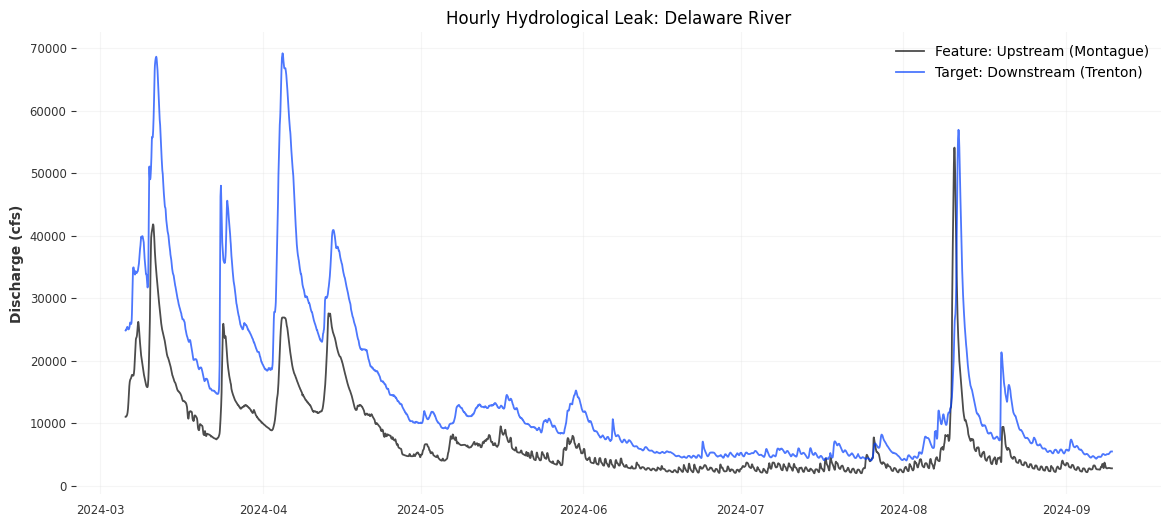

(4500, 2)
Peak Correlation is at lag: 14 hours


In [5]:
import dataretrieval.nwis as nwis

# 1. Define the Gauge IDs
# # Upstream: Montague, NJ
upstream_id = '01438500' 

# # Downstream: Trenton, NJ (approx 100 miles downstream)
downstream_id = '01463500'

# 2. Fetch Daily Mean Discharge (Parameter '00060')
# Fetching 2 years of data
start_date = '2024-01-01'
end_date = '2024-12-31'

# service = 'dv' #daily
service = 'iv' #instantaneous (approx 15 mins), resample to hourly

df_up = nwis.get_record(sites=upstream_id, service=service, start=start_date, end=end_date, parameterCd='00060')
df_down = nwis.get_record(sites=downstream_id, service=service, start=start_date, end=end_date, parameterCd='00060')

# The raw data is usually 15-min. We resample to 'H' (Hourly) and take the mean.
# We also handle timezone conversion to ensure alignment.
def clean_and_hourly(df):
    # Ensure index is datetime (UTC usually, but we make sure)
    df.index = pd.to_datetime(df.index, utc=True)
    # Resample to hourly mean
    return df['00060'].resample('h').mean()

ts_up = clean_and_hourly(df_up)
ts_down = clean_and_hourly(df_down)

# 4. Merge
df_hourly = pd.DataFrame({
    'Upstream_Montague': ts_up,
    'Downstream_Trenton': ts_down
}).dropna()
df_hourly = df_hourly.iloc[1500:6000]
print(df_hourly.shape)



# 5. Visualize the Hourly Detail
plt.figure(figsize=(14, 6))
# Plot only a 2-week slice so you can see the hourly lag clearly
subset = df_hourly.iloc[0:]#336] # First 2 weeks (14 days * 24 hours)

plt.plot(subset.index, subset['Upstream_Montague'], label='Feature: Upstream (Montague)', alpha=0.7)
plt.plot(subset.index, subset['Downstream_Trenton'], label='Target: Downstream (Trenton)', alpha=0.7)
plt.title("Hourly Hydrological Leak: Delaware River")
plt.ylabel("Discharge (cfs)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Check Lag Correlation at Hourly Resolution
# Check lags from 0 to 48 hours
lags = range(-49, 49)
corrs = [df_hourly['Upstream_Montague'].shift(lag).corr(df_hourly['Downstream_Trenton']) for lag in lags]

# Find the peak lag
peak_lag = lags[corrs.index(max(corrs))]
print(df_hourly.shape)
print(f"Peak Correlation is at lag: {peak_lag} hours")

In [65]:
df_hourly

,Upstream_Montague,Downstream_Trenton
datetime,,
2024-03-05 19:00:00+00:00,11000.0,24825.0
2024-03-05 20:00:00+00:00,11000.0,24900.0
2024-03-05 21:00:00+00:00,11025.0,24900.0
2024-03-05 22:00:00+00:00,11100.0,25000.0
2024-03-05 23:00:00+00:00,11100.0,25050.0
...,...,...
2024-09-09 14:00:00+00:00,2750.0,5450.0
2024-09-09 15:00:00+00:00,2750.0,5450.0
2024-09-09 16:00:00+00:00,2750.0,5450.0


In [66]:
# This adds any missing rows and assigns a 'freq' attribute
df_hourly = df_hourly.resample('H').ffill()

# Check if frequency is now assigned
print(f"Inferred Frequency: {df_hourly.index.freq}")

Inferred Frequency: <Hour>


In [8]:
# Set REPO_ROOT if not set
if os.getenv("REPO_ROOT") is None:
    os.environ["REPO_ROOT"] = "."

### 1. NVIDIA Dataset - Chronos2 Multivariate

**Note:** If you see `Can't initialize NVML` or no GPU, pass `device="cpu"` to use CPU. The first run downloads the Chronos2 model (~478MB); progress may show 0% in the IDE. `LookupError: shell_parent` is an IDE progress quirk—safe to ignore.

Training: up to 1759 samples. Test: last 432, 27 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/27: train length=1759
  Fold 2/27: train length=1775
  Fold 3/27: train length=1791
  Fold 4/27: train length=1807
  Fold 5/27: train length=1823
  Fold 6/27: train length=1839
  Fold 7/27: train length=1855
  Fold 8/27: train length=1871
  Fold 9/27: train length=1887
  Fold 10/27: train length=1903
  Fold 11/27: train length=1919
  Fold 12/27: train length=1935
  Fold 13/27: train length=1951
  Fold 14/27: train length=1967
  Fold 15/27: train length=1983
  Fold 16/27: train length=1999
  Fold 17/27: train length=2015
  Fold 18/27: train length=2031
  Fold 19/27: train length=2047
  Fold 20/27: train length=2063
  Fold 21/27: train length=2079
  Fold 22/27: train length=2095
  Fold 23/27: train length=2111
  Fold 24/27: train length=2127
  Fold 25/27: train length=2143
  Fold 26/27: train length=2159
  Fold 27/27: train length=2175

Forecast completed. Total forecast shape: (

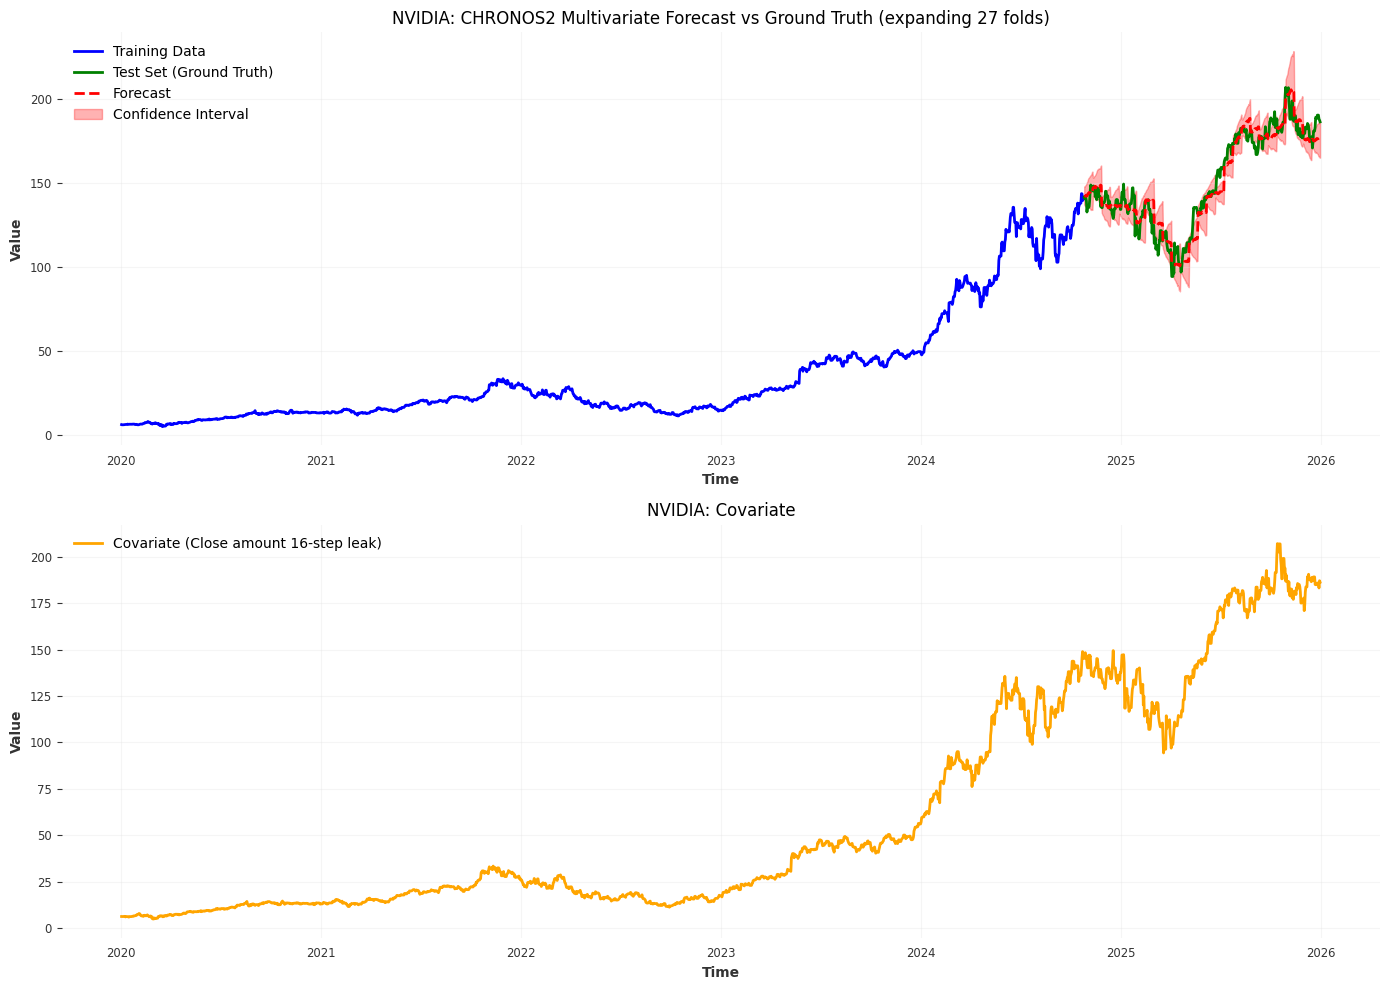

In [72]:
results_nvidia_chronos2_multi = run_forecasting_experiment(
    model_type="chronos2",
    dataset_name="nvidia",
    y_column="Close amount",
    x_column="Close amount 16-step leak",
    forecast_horizon=16,
    use_covariate=True,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_nvidia_w_leak,
)

### 2. NVIDIA Dataset - Chronos2 Univariate

Training: up to 1759 samples. Test: last 432, 27 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/27: train length=1759
  Fold 2/27: train length=1775
  Fold 3/27: train length=1791
  Fold 4/27: train length=1807
  Fold 5/27: train length=1823
  Fold 6/27: train length=1839
  Fold 7/27: train length=1855
  Fold 8/27: train length=1871
  Fold 9/27: train length=1887
  Fold 10/27: train length=1903
  Fold 11/27: train length=1919
  Fold 12/27: train length=1935
  Fold 13/27: train length=1951
  Fold 14/27: train length=1967
  Fold 15/27: train length=1983
  Fold 16/27: train length=1999
  Fold 17/27: train length=2015
  Fold 18/27: train length=2031
  Fold 19/27: train length=2047
  Fold 20/27: train length=2063
  Fold 21/27: train length=2079
  Fold 22/27: train length=2095
  Fold 23/27: train length=2111
  Fold 24/27: train length=2127
  Fold 25/27: train length=2143
  Fold 26/27: train length=2159
  Fold 27/27: train length=2175

Forecast completed. Total forecast shape: (

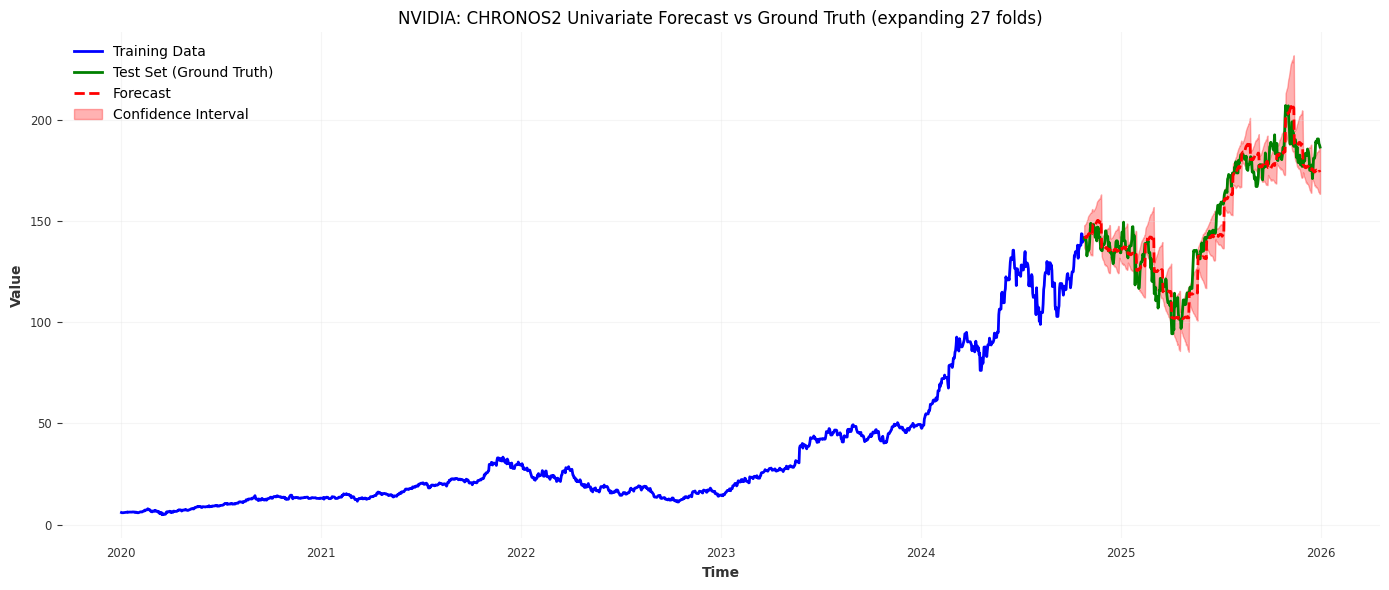

In [73]:
results_nvidia_chronos2_uni = run_forecasting_experiment(
    model_type="chronos2",
    dataset_name="nvidia",
    y_column="Close amount",
    forecast_horizon=16,
    use_covariate=False,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_nvidia_w_leak,
)

### 3. COVID Dataset - Chronos2 Multivariate

Training: up to 40 samples. Test: last 10, 10 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/10: train length=40
  Fold 2/10: train length=41
  Fold 3/10: train length=42
  Fold 4/10: train length=43
  Fold 5/10: train length=44
  Fold 6/10: train length=45
  Fold 7/10: train length=46
  Fold 8/10: train length=47
  Fold 9/10: train length=48
  Fold 10/10: train length=49

Forecast completed. Total forecast shape: (10,), y_test shape: (10,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 50.2731
 MSE: 4400.9112
 RMSE: 66.3394
 MAPE: 0.2400
 SMAPE: 0.2206
 ND: 0.2383
 NRMSE: 0.3144
 MASE: 1.7109
 MAR: 0.7666
 MBR: 0.4000
 MSIS: nan

Generating plot...


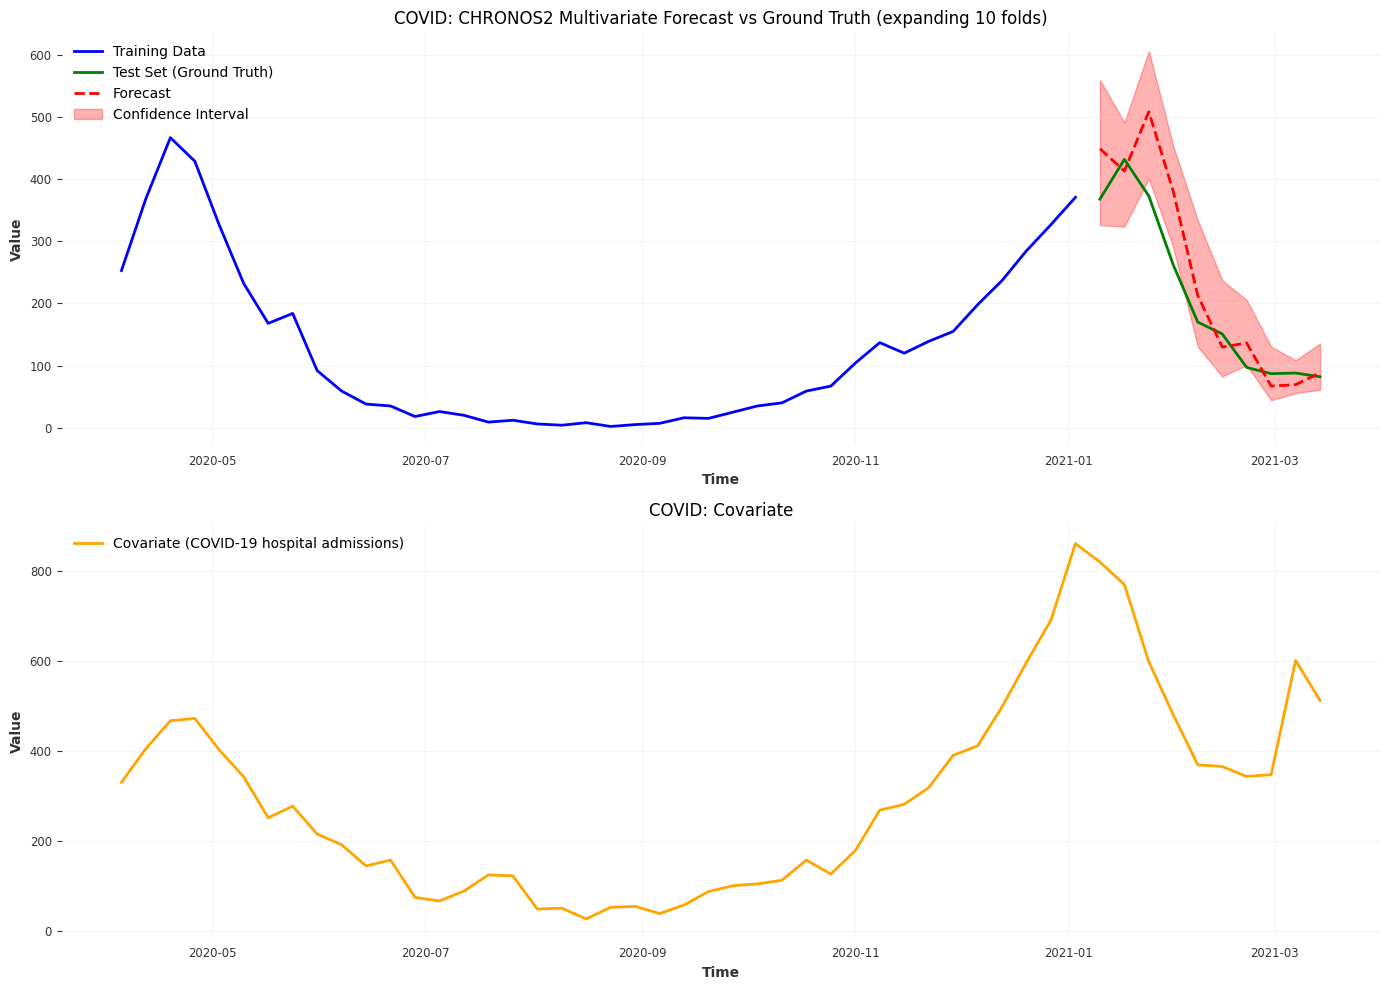

In [ ]:
results_covid_chronos2_multi = run_forecasting_experiment(
    model_type="chronos2",
    dataset_name="covid",
    y_column="COVID-19 deaths",
    x_column="COVID-19 hospital admissions",
    forecast_horizon=1,
    use_covariate=True,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_covid,
)

### 4. COVID Dataset - Chronos2 Univariate

Training: up to 40 samples. Test: last 10, 10 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/10: train length=40
  Fold 2/10: train length=41
  Fold 3/10: train length=42
  Fold 4/10: train length=43
  Fold 5/10: train length=44
  Fold 6/10: train length=45
  Fold 7/10: train length=46
  Fold 8/10: train length=47
  Fold 9/10: train length=48
  Fold 10/10: train length=49

Forecast completed. Total forecast shape: (10,), y_test shape: (10,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 50.2690
 MSE: 4350.4501
 RMSE: 65.9579
 MAPE: 0.2411
 SMAPE: 0.2262
 ND: 0.2382
 NRMSE: 0.3126
 MASE: 1.7107
 MAR: 0.7627
 MBR: 0.4000
 MSIS: nan

Generating plot...


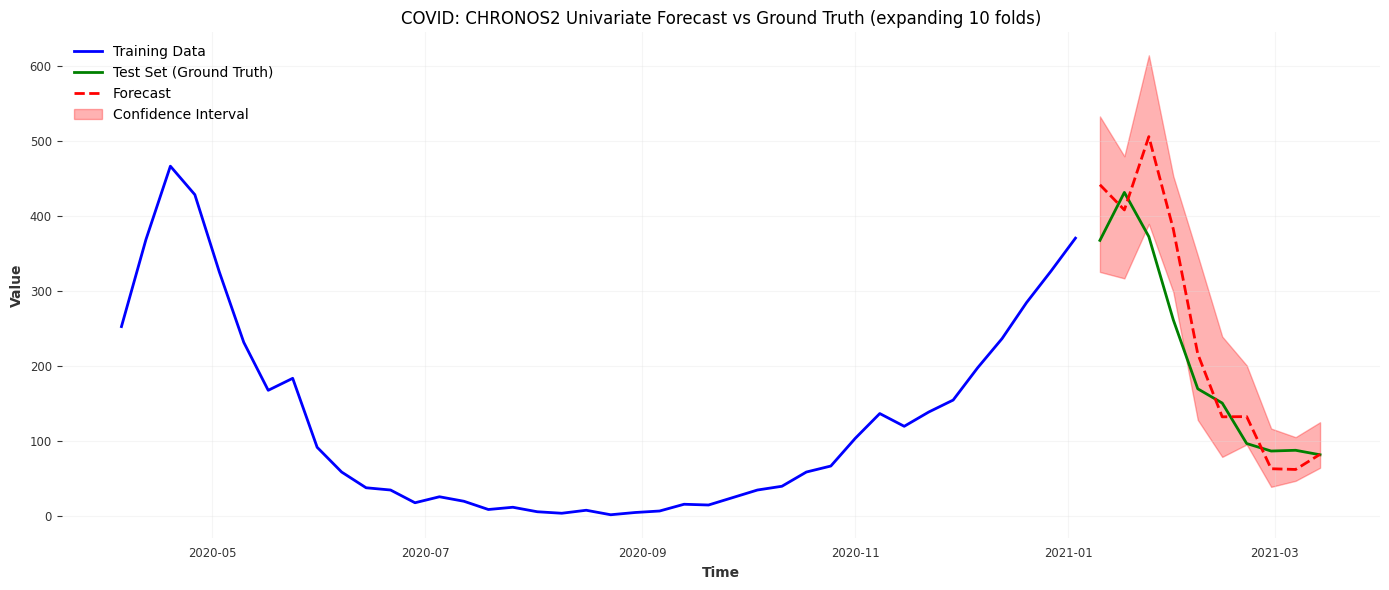

In [ ]:
results_covid_chronos2_uni = run_forecasting_experiment(
    model_type="chronos2",
    dataset_name="covid",
    y_column="COVID-19 deaths",
    forecast_horizon=1,
    use_covariate=False,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_covid,
)

### 5. NVIDIA Dataset - DLinear Multivariate

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training: up to 1759 samples. Test: last 432, 27 folds.
Starting HPO Cross-Validation (10 folds) for DLinear...
current hyper value:  8


/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


  Fold 27/27: train length=2175


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Forecast completed. Total forecast shape: (432,), y_test shape: (432,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 2.5658
 MSE: 11.4709
 RMSE: 3.3869
 MAPE: 0.0177
 SMAPE: 0.0177
 ND: 0.0169
 NRMSE: 0.0224
 MASE: 4.2978
 MAR: 0.9988
 MBR: 0.4792
 MSIS: nan

Generating plot...


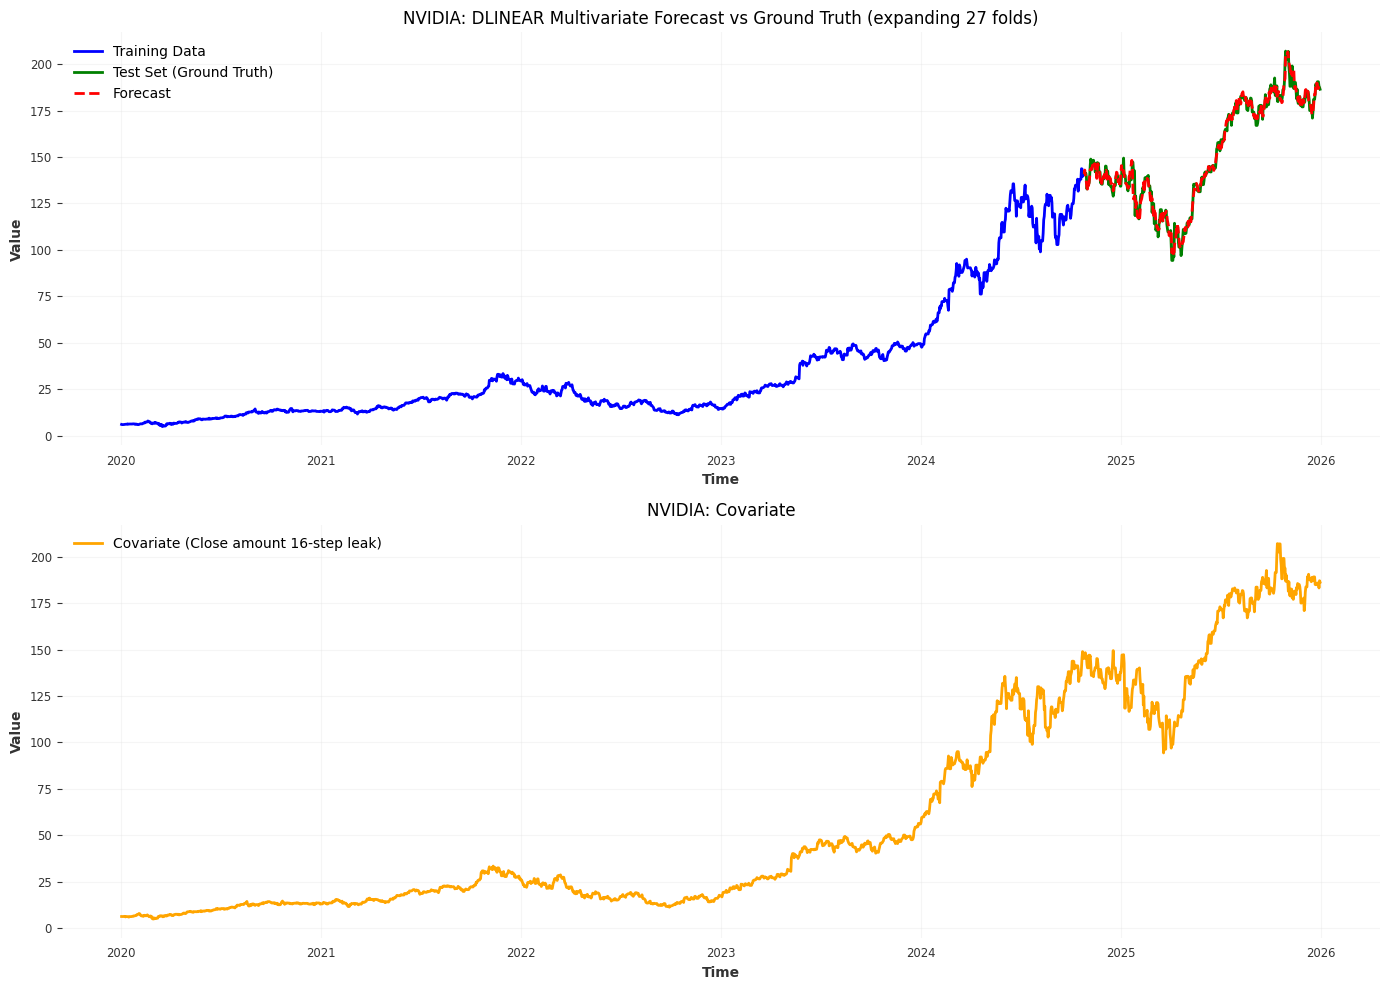

In [32]:
results_nvidia_dlinear_multi = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="nvidia",
    y_column="Close amount",
    x_column="Close amount 16-step leak",
    forecast_horizon=16,
    use_covariate=True,
    seasonal_frequency=1,
    #lookback_window=16,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_nvidia_w_leak,
    hpo_flag = True,
    grid_search_list = [8,16,32,64]
)

### 6. NVIDIA Dataset - DLinear Univariate

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Training: up to 1759 samples. Test: last 432, 27 folds.
Starting HPO Cross-Validation (10 folds) for DLinear...
current hyper value:  8


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


  Fold 27/27: train length=2175


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Forecast completed. Total forecast shape: (432,), y_test shape: (432,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 6.7388
 MSE: 71.7555
 RMSE: 8.4709
 MAPE: 0.0467
 SMAPE: 0.0465
 ND: 0.0445
 NRMSE: 0.0560
 MASE: 11.2876
 MAR: 0.9976
 MBR: 0.4606
 MSIS: nan

Generating plot...


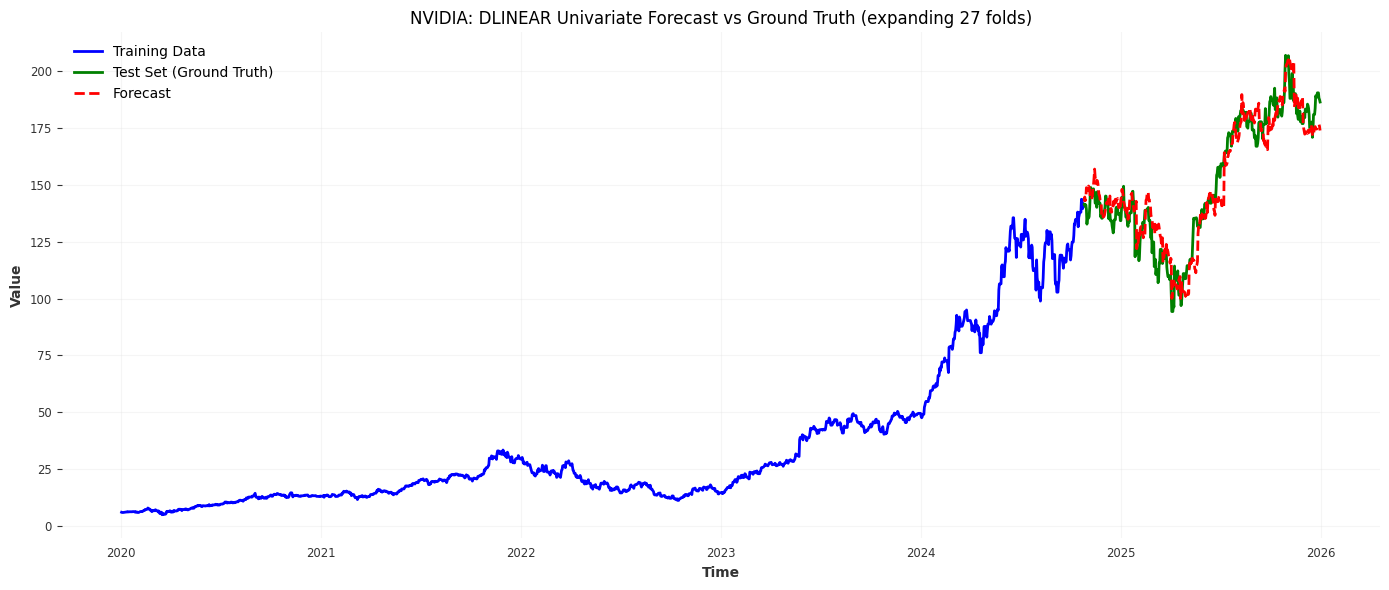

In [33]:
results_nvidia_dlinear_uni = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="nvidia",
    y_column="Close amount",
    forecast_horizon=16,
    use_covariate=False,
    seasonal_frequency=1,
    #lookback_window=16,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_nvidia_w_leak,
    hpo_flag = True,
    grid_search_list = [8,16,32,64],

)

### 7. COVID Dataset - DLinear Multivariate

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training: up to 40 samples. Test: last 10, 10 folds.
Starting HPO Cross-Validation (4 folds) for DLinear...
current hyper value:  1


/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


  Fold 10/10: train length=49


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Forecast completed. Total forecast shape: (10,), y_test shape: (10,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 90.5555
 MSE: 9216.1779
 RMSE: 96.0009
 MAPE: 0.6576
 SMAPE: 0.4547
 ND: 0.4292
 NRMSE: 0.4550
 MASE: 3.0817
 MAR: 0.6589
 MBR: 0.4000
 MSIS: nan

Generating plot...


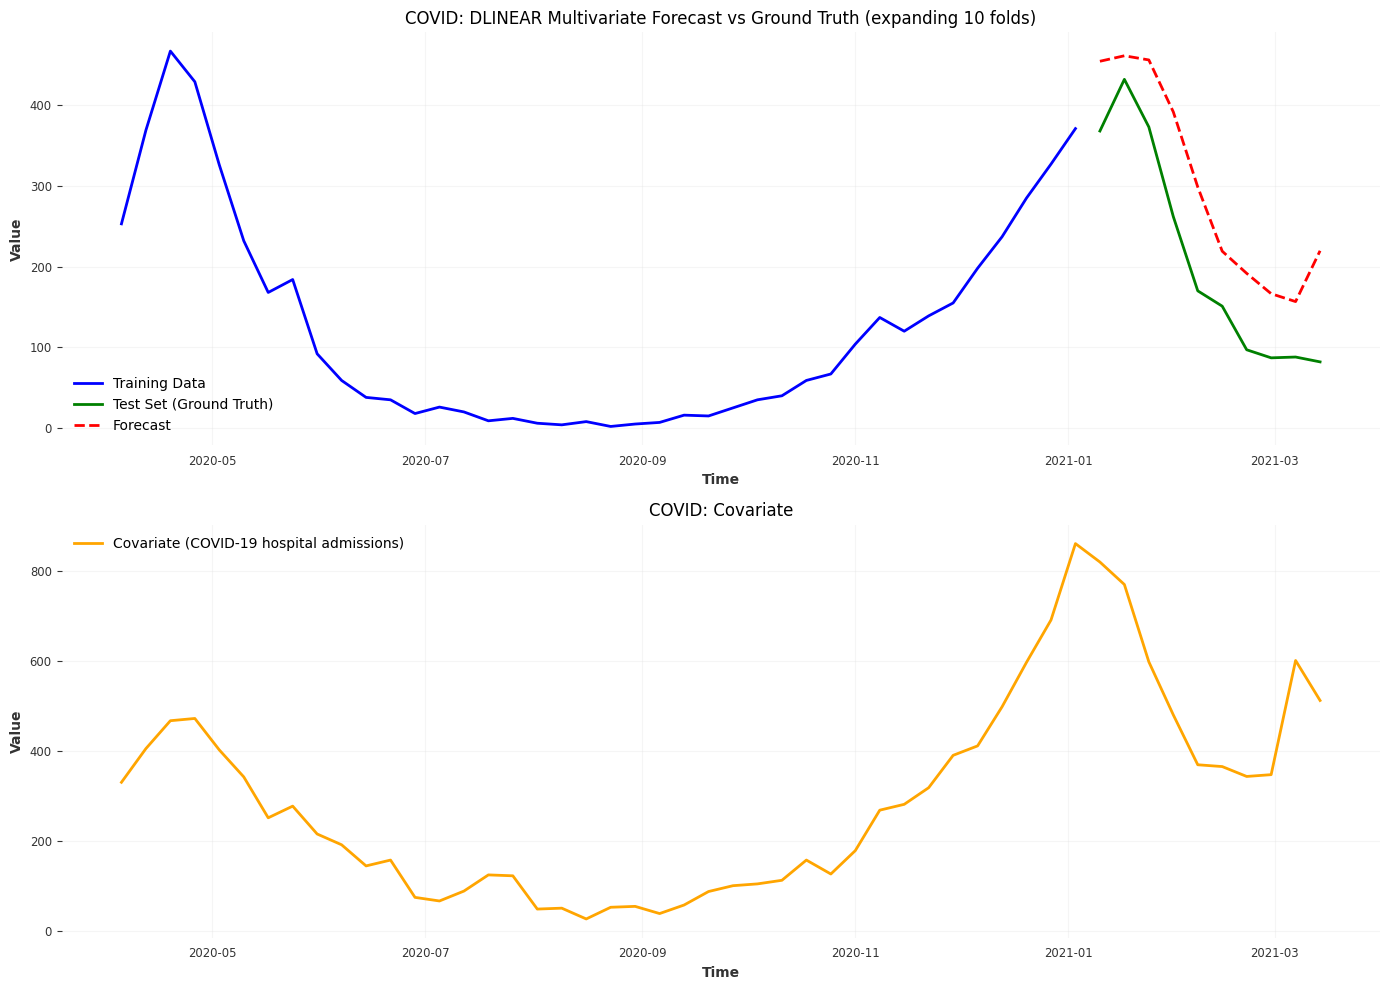

In [35]:
results_covid_dlinear_multi = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="covid",
    y_column="COVID-19 deaths",
    x_column="COVID-19 hospital admissions",
    forecast_horizon=1,
    use_covariate=True,
    seasonal_frequency=1,
    #lookback_window=15,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_covid,
    hpo_flag = True,
    grid_search_list = [1,2,4,8,16]
)

### 8. COVID Dataset - DLinear Univariate

Training: up to 40 samples. Test: last 10, 10 folds.
Starting HPO Cross-Validation (4 folds) for DLinear...
current hyper value:  1


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


  Fold 10/10: train length=49


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Forecast completed. Total forecast shape: (10,), y_test shape: (10,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 40.0314
 MSE: 3052.2913
 RMSE: 55.2475
 MAPE: 0.1993
 SMAPE: 0.1706
 ND: 0.1897
 NRMSE: 0.2618
 MASE: 1.3623
 MAR: 0.8527
 MBR: 0.5000
 MSIS: nan

Generating plot...


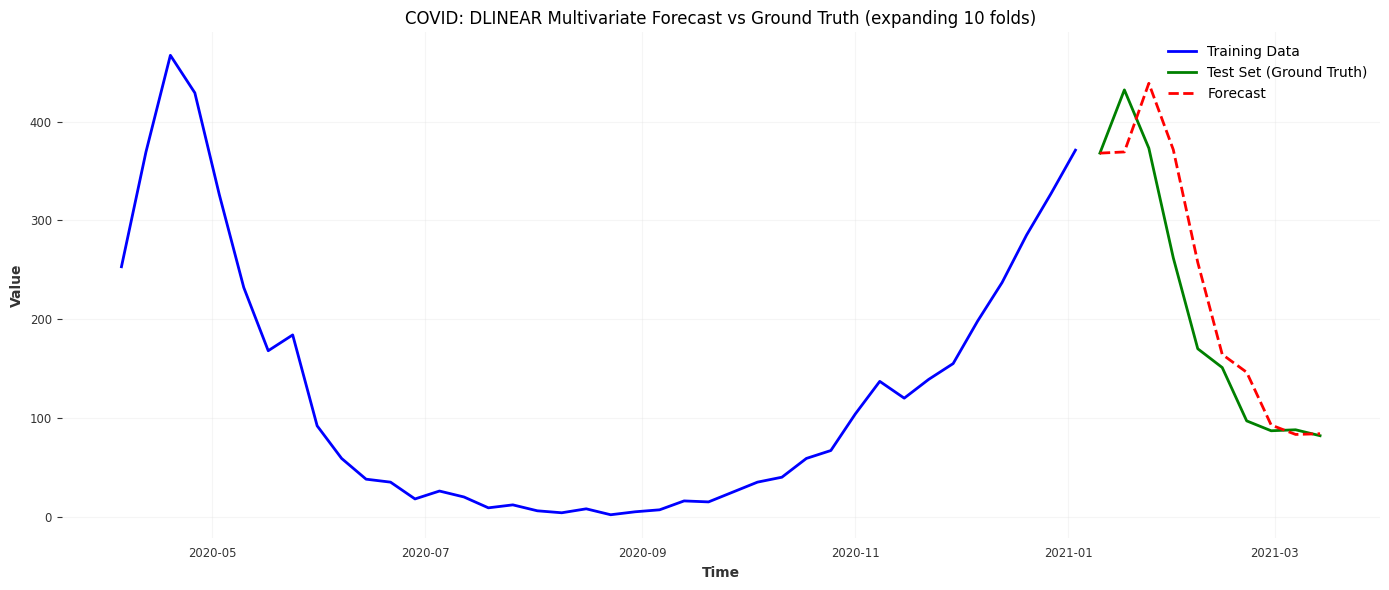

In [ ]:
results_covid_dlinear_uni = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="covid",
    y_column="COVID-19 deaths",
    forecast_horizon=1,
    use_covariate=False,
    seasonal_frequency=1,
    lookback_window=15,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_covid,
    hpo_flag = True,
    grid_search_list = [1,2,4,8,16]
    )

Training: up to 3616 samples. Test: last 896, 64 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/64: train length=3616
  Fold 2/64: train length=3630
  Fold 3/64: train length=3644
  Fold 4/64: train length=3658
  Fold 5/64: train length=3672
  Fold 6/64: train length=3686
  Fold 7/64: train length=3700
  Fold 8/64: train length=3714
  Fold 9/64: train length=3728
  Fold 10/64: train length=3742
  Fold 11/64: train length=3756
  Fold 12/64: train length=3770
  Fold 13/64: train length=3784
  Fold 14/64: train length=3798
  Fold 15/64: train length=3812
  Fold 16/64: train length=3826
  Fold 17/64: train length=3840
  Fold 18/64: train length=3854
  Fold 19/64: train length=3868
  Fold 20/64: train length=3882
  Fold 21/64: train length=3896
  Fold 22/64: train length=3910
  Fold 23/64: train length=3924
  Fold 24/64: train length=3938
  Fold 25/64: train length=3952
  Fold 26/64: train length=3966
  Fold 27/64: train length=3980
  Fold 28/64: train length=3994
  Fold 29/64

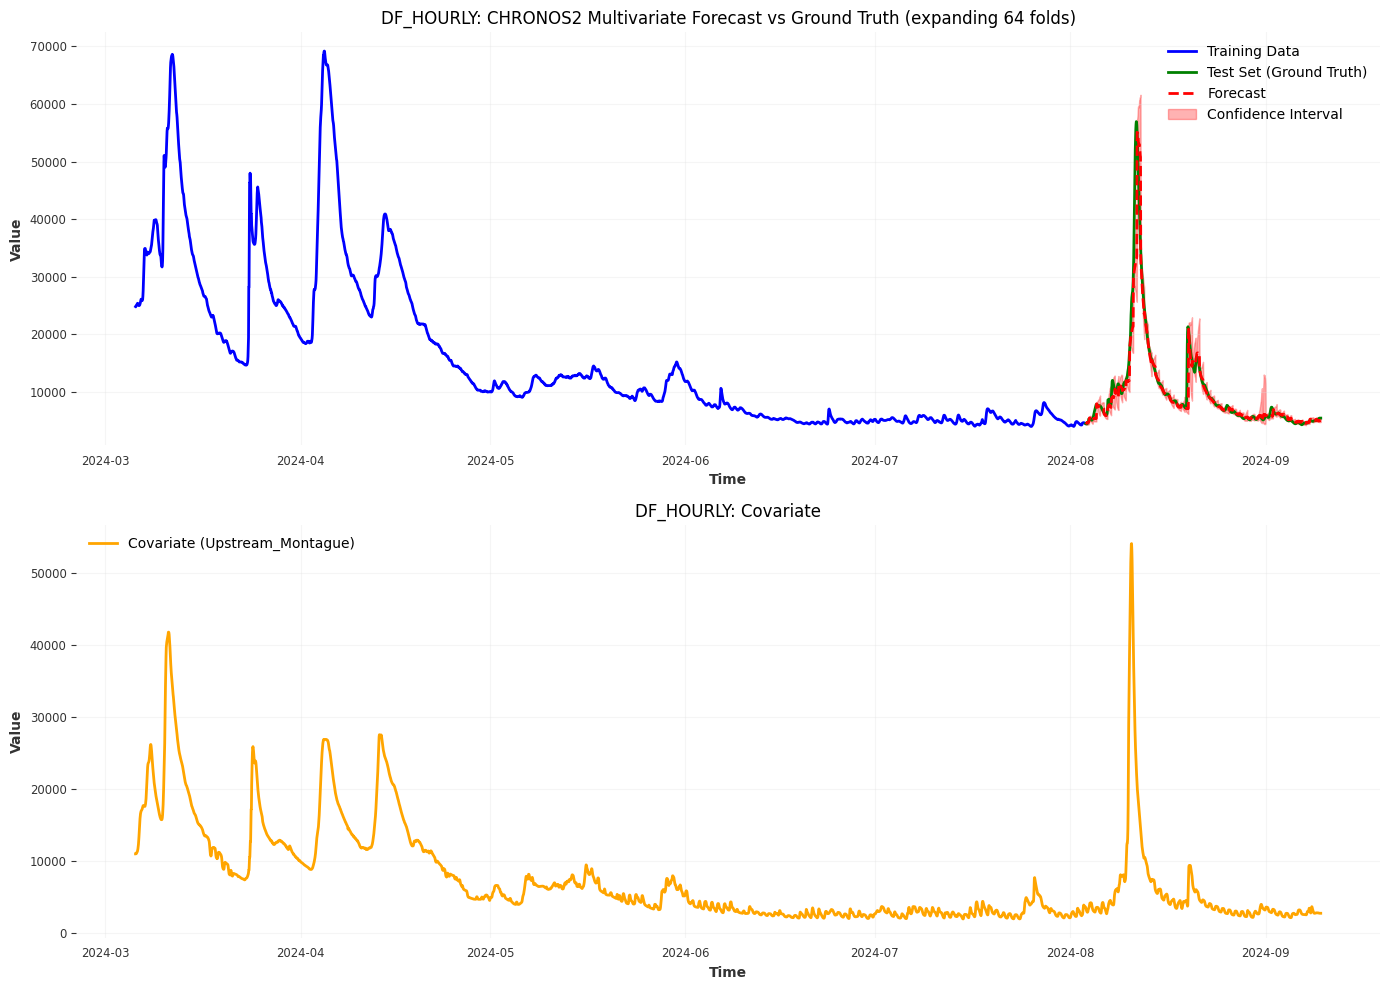

In [70]:
# river chronos2 multi
results_river_chronos2_multi = run_forecasting_experiment(
    dataset_name = 'df_hourly',
    model_type="chronos2",
    y_column="Downstream_Trenton",
    x_column="Upstream_Montague",
    forecast_horizon=14,
    use_covariate=True,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_hourly,
)

Training: up to 3616 samples. Test: last 896, 64 folds.
Loading Chronos-2 from local cache on CPU...
  Fold 1/64: train length=3616
  Fold 2/64: train length=3630
  Fold 3/64: train length=3644
  Fold 4/64: train length=3658
  Fold 5/64: train length=3672
  Fold 6/64: train length=3686
  Fold 7/64: train length=3700
  Fold 8/64: train length=3714
  Fold 9/64: train length=3728
  Fold 10/64: train length=3742
  Fold 11/64: train length=3756
  Fold 12/64: train length=3770
  Fold 13/64: train length=3784
  Fold 14/64: train length=3798
  Fold 15/64: train length=3812
  Fold 16/64: train length=3826
  Fold 17/64: train length=3840
  Fold 18/64: train length=3854
  Fold 19/64: train length=3868
  Fold 20/64: train length=3882
  Fold 21/64: train length=3896
  Fold 22/64: train length=3910
  Fold 23/64: train length=3924
  Fold 24/64: train length=3938
  Fold 25/64: train length=3952
  Fold 26/64: train length=3966
  Fold 27/64: train length=3980
  Fold 28/64: train length=3994
  Fold 29/64

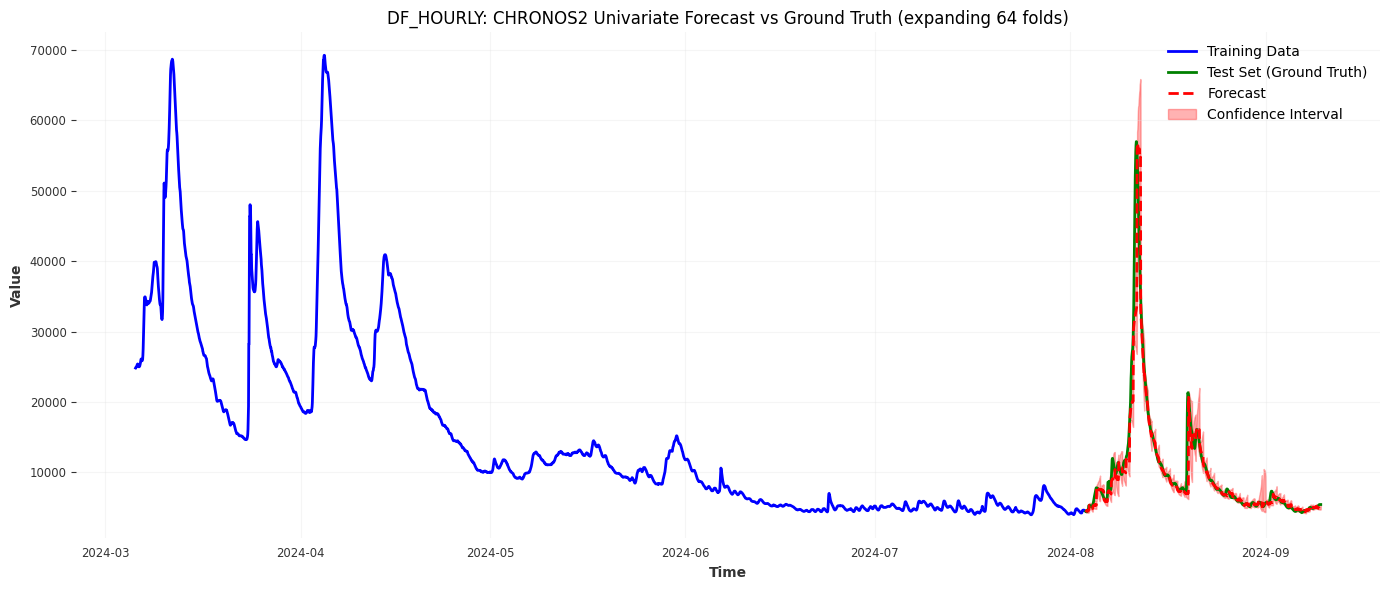

In [75]:
# river chronos2 uni
results_river_chronos2_uni = run_forecasting_experiment(
    dataset_name = 'df_hourly',
    model_type="chronos2",
    y_column="Downstream_Trenton",
    forecast_horizon=14,
    use_covariate=False,
    seasonal_frequency=1,
    plot=True,
    calculate_metrics_flag=True,
    df=df_hourly,
)

In [ ]:
results_river_dlinear_multi = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="df_hourly",
    y_column="Downstream_Trenton",
    x_column="Upstream_Montague",
    forecast_horizon=14,
    use_covariate=True,
    seasonal_frequency=1,
    lookback_window=14,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_hourly,
    #hpo_flag = True,
    #grid_search_list = [7,14,28,56]
)

/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(to

Training: up to 3600 samples. Test: last 900, 30 folds.
Starting HPO Cross-Validation (12 folds) for DLinear...
current hyper value:  7


/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Training: up to 3616 samples. Test: last 896, 64 folds.
  Fold 1/64: train length=3616


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


...

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zoey/Repo/timeseries-research/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


  Fold 64/64: train length=4498


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


Forecast completed. Total forecast shape: (896,), y_test shape: (896,)

Calculating metrics (concat all folds, aggregate)...

Metrics:
 MAE: 1181.3168
 MSE: 12839186.0550
 RMSE: 3583.1810
 MAPE: 0.0716
 SMAPE: 0.0752
 ND: 0.1174
 NRMSE: 0.3560
 MASE: 8.8207
 MAR: 0.9855
 MBR: 0.5234
 MSIS: nan

Generating plot...


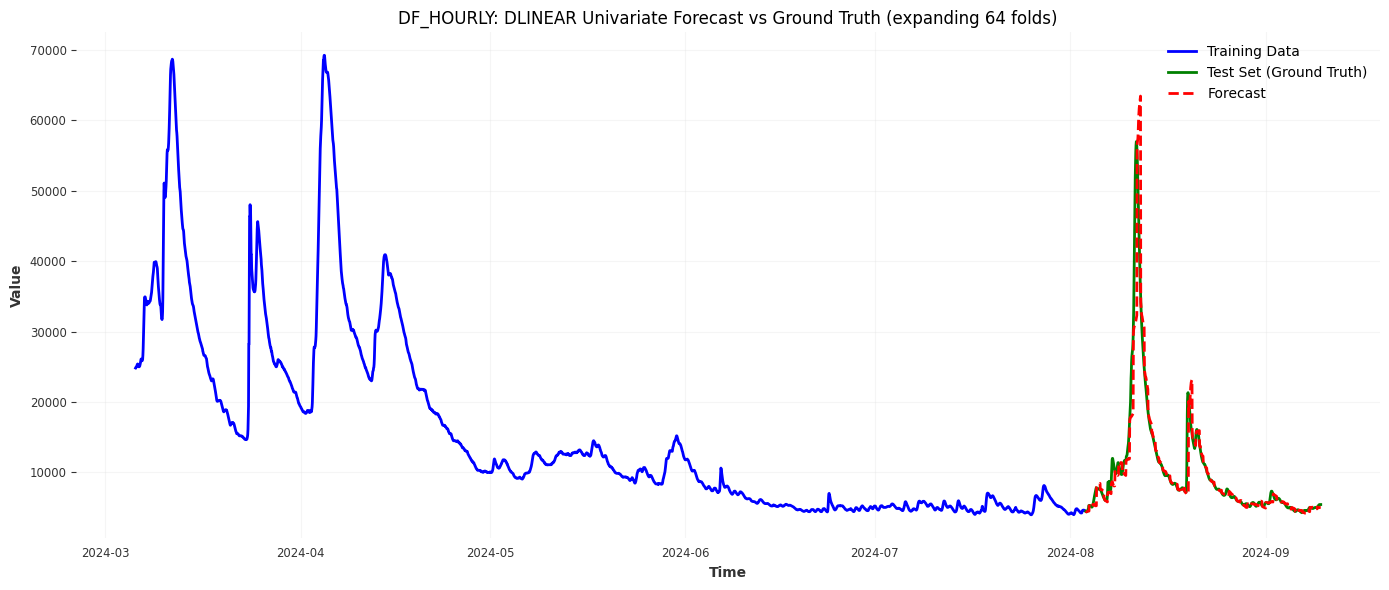

In [ ]:
# river dlinear uni
results_river_dlinear_uni = run_forecasting_experiment(
    model_type="dlinear",
    dataset_name="df_hourly",
    y_column="Downstream_Trenton",
    forecast_horizon=14,
    use_covariate=False,
    seasonal_frequency=1,
    lookback_window=14,
    n_epochs=50,
    plot=True,
    calculate_metrics_flag=True,
    df=df_hourly,
    #hpo_flag = True,
    #rid_search_list = [7,14,28,56]
    )

## Summary: Compare All Results

Create a summary table comparing all experiments.

In [81]:
# Collect all results into a summary DataFrame
summary_data = []

experiments = [
    ("NVIDIA", "Chronos2", "Multivariate", results_nvidia_chronos2_multi),
    ("NVIDIA", "Chronos2", "Univariate", results_nvidia_chronos2_uni),
    ("NVIDIA", "DLinear", "Multivariate", results_nvidia_dlinear_multi),
    ("NVIDIA", "DLinear", "Univariate", results_nvidia_dlinear_uni),
    ("COVID", "Chronos2", "Multivariate", results_covid_chronos2_multi),
    ("COVID", "Chronos2", "Univariate", results_covid_chronos2_uni),
    ("COVID", "DLinear", "Multivariate", results_covid_dlinear_multi),
    ("COVID", "DLinear", "Univariate", results_covid_dlinear_uni),
    ("RIVER", "Chronos2", "Multivariate", results_river_chronos2_multi),
    ("RIVER", "Chronos2", "Univariate", results_river_chronos2_uni),
    ("RIVER", "Dlinear", "Multivariate", results_river_dlinear_multi),
    ("RIVER", "Dlinear", "Univariate", results_river_dlinear_uni),

]

for dataset, model, mode, results in experiments:
    if results and results.get('metrics'):
        metrics = results['metrics']
        summary_data.append({
            'Dataset': dataset,
            'Model': model,
            'Mode': mode,
            'MAE': metrics.get('MAE', np.nan),
            'MSE': metrics.get('MSE', np.nan),
            'RMSE': metrics.get('RMSE', np.nan),
            'MAPE': metrics.get('MAPE', np.nan),
            'SMAPE': metrics.get('SMAPE', np.nan),
            'ND': metrics.get('ND', np.nan),
            'NRMSE': metrics.get('NRMSE', np.nan),
            'MASE': metrics.get('MASE', np.nan),
            'MAR': metrics.get('MAR', np.nan),
            'MBR': metrics.get('MBR', np.nan),
        })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*80)
print(summary_df.to_string(index=False))

#


SUMMARY OF ALL EXPERIMENTS
Dataset    Model         Mode         MAE          MSE        RMSE     MAPE    SMAPE       ND    NRMSE      MASE      MAR      MBR
 NVIDIA Chronos2 Multivariate    5.912077 5.778914e+01    7.601917 0.040549 0.040678 0.039051 0.050213  9.902845 1.005940 0.557870
 NVIDIA Chronos2   Univariate    6.301918 6.576438e+01    8.109524 0.043197 0.043375 0.041626 0.053566 10.555836 1.006438 0.541667
 NVIDIA  DLinear Multivariate    2.565810 1.147093e+01    3.386876 0.017742 0.017745 0.016948 0.022372  4.297783 0.998779 0.479167
 NVIDIA  DLinear   Univariate    6.738812 7.175555e+01    8.470864 0.046745 0.046536 0.044512 0.055953 11.287642 0.997583 0.460648
  COVID Chronos2 Multivariate   50.273118 4.400911e+03   66.339364 0.240017 0.220603 0.238261 0.314405  1.710865 0.766647 0.400000
  COVID Chronos2   Univariate   50.268984 4.350450e+03   65.957942 0.241097 0.226214 0.238242 0.312597  1.710725 0.762656 0.400000
  COVID  DLinear Multivariate   90.555512 9.216178e+03 

In [82]:
def merge_forecast_to_df(df, forecast_results, model_name, mode):
    """
    Merges the concatenated forecast array back into the original dataframe.
    
    Args:
        df: The original (resampled/filled) DataFrame.
        forecast_results: The dictionary returned by run_forecasting_experiment.
        model_name: string (e.g., 'chronos2', 'dlinear')
        mode: string (e.g., 'multi', 'uni')
        
    Returns:
        DataFrame with a new column: 'forecast_{model_name}_{mode}'
    """
    # Create a copy to avoid SettingWithCopy warnings
    df_out = df.copy()
    
    forecast_array = forecast_results['forecast']
    
    # The forecast starts exactly where the training ended globally
    # In your experiment: train_end_global = len(y) - test_size
    test_size = len(forecast_array)
    start_idx = len(df_out) - test_size
    
    # Create the dynamic column name
    col_name = f"forecast_{model_name.lower()}_{mode.lower()}"
    
    # Initialize the column with NaNs
    df_out[col_name] = np.nan
    
    # Place the forecast values into the correct slice
    # Using .iloc to ensure we match by integer position
    df_out.iloc[start_idx:, df_out.columns.get_loc(col_name)] = forecast_array
    
    print(f"Merged {len(forecast_array)} predictions into column: {col_name}")
    return df_out

In [ ]:
experiments = [
    ("NVIDIA", "Chronos2", "Multivariate", results_nvidia_chronos2_multi),
    ("NVIDIA", "Chronos2", "Univariate", results_nvidia_chronos2_uni),
    ("NVIDIA", "DLinear", "Multivariate", results_nvidia_dlinear_multi),
    ("NVIDIA", "DLinear", "Univariate", results_nvidia_dlinear_uni),]

df_nvidia_pred = df_nvidia_w_leak.copy()
for dataset, model, mode, results in experiments:
    df_nvidia_pred = merge_forecast_to_df(df_nvidia_pred, results, model, mode)
display(df_nvidia_pred)
RESULTS = Path("../results_shared/real_data")
df_nvidia_pred.to_csv(RESULTS / "df_nvidia_pred.csv")

Merged 432 predictions into column: forecast_chronos2_multivariate
Merged 432 predictions into column: forecast_chronos2_univariate
Merged 432 predictions into column: forecast_dlinear_multivariate
Merged 432 predictions into column: forecast_dlinear_univariate


,Date,Close amount,Close amount 16-step leak,forecast_chronos2_multivariate,forecast_chronos2_univariate,forecast_dlinear_multivariate,forecast_dlinear_univariate
0,2020-01-02,6.00,6.23,NaN,NaN,NaN,NaN
1,2020-01-03,5.90,6.20,NaN,NaN,NaN,NaN
2,2020-01-04,5.90,6.20,NaN,NaN,NaN,NaN
3,2020-01-05,5.90,6.20,NaN,NaN,NaN,NaN
4,2020-01-06,5.93,6.25,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2186,2025-12-27,190.53,185.81,176.393707,175.029663,186.835523,175.584302
2187,2025-12-28,190.53,185.81,175.402313,174.036423,186.939537,176.376397
2188,2025-12-29,188.22,183.14,175.947540,174.518295,187.397054,176.675806
2189,2025-12-30,187.54,187.05,176.045059,174.575455,186.294869,175.755860


In [ ]:
experiments = [
    ("COVID", "Chronos2", "Multivariate", results_covid_chronos2_multi),
    ("COVID", "Chronos2", "Univariate", results_covid_chronos2_uni),
    ("COVID", "DLinear", "Multivariate", results_covid_dlinear_multi),
    ("COVID", "DLinear", "Univariate", results_covid_dlinear_uni)]
df_covid_pred = df_covid.copy()
for dataset, model, mode, results in experiments:
    df_covid_pred = merge_forecast_to_df(df_covid_pred, results, model, mode)
display(df_covid_pred)
df_covid_pred.to_csv(RESULTS"df_covid_pred.csv")

Merged 10 predictions into column: forecast_chronos2_multivariate
Merged 10 predictions into column: forecast_chronos2_univariate
Merged 10 predictions into column: forecast_dlinear_multivariate
Merged 10 predictions into column: forecast_dlinear_univariate


,Week start date,COVID-19 deaths,COVID-19 hospital admissions,forecast_chronos2_multivariate,forecast_chronos2_univariate,forecast_dlinear_multivariate,forecast_dlinear_univariate
Week start date,,,,,,,
2020-04-05,2020-04-05 00:00:00,253,331,NaN,NaN,NaN,NaN
2020-04-12,2020-04-12 00:00:00,369,406,NaN,NaN,NaN,NaN
2020-04-19,2020-04-19 00:00:00,467,468,NaN,NaN,NaN,NaN
2020-04-26,2020-04-26 00:00:00,429,473,NaN,NaN,NaN,NaN
2020-05-03,2020-05-03 00:00:00,326,403,NaN,NaN,NaN,NaN
2020-05-10,2020-05-10 00:00:00,232,343,NaN,NaN,NaN,NaN
2020-05-17,2020-05-17 00:00:00,168,252,NaN,NaN,NaN,NaN
2020-05-24,2020-05-24 00:00:00,184,278,NaN,NaN,NaN,NaN
2020-05-31,2020-05-31 00:00:00,92,216,NaN,NaN,NaN,NaN


In [90]:
experiments = [
    ("RIVER", "Chronos2", "Multivariate", results_river_chronos2_multi),
    ("RIVER", "Chronos2", "Univariate", results_river_chronos2_uni),
    ("RIVER", "Dlinear", "Multivariate", results_river_dlinear_multi),
    ("RIVER", "Dlinear", "Univariate", results_river_dlinear_uni),]

df_river_pred = df_hourly.copy()
for dataset, model, mode, results in experiments:
    df_river_pred = merge_forecast_to_df(df_river_pred, results, model, mode)
display(df_river_pred)
df_river_pred.to_csv("df_river_pred.csv")

Merged 896 predictions into column: forecast_chronos2_multivariate
Merged 896 predictions into column: forecast_chronos2_univariate
Merged 896 predictions into column: forecast_dlinear_multivariate
Merged 896 predictions into column: forecast_dlinear_univariate


,Upstream_Montague,Downstream_Trenton,forecast_chronos2_multivariate,forecast_chronos2_univariate,forecast_dlinear_multivariate,forecast_dlinear_univariate
datetime,,,,,,
2024-03-05 19:00:00+00:00,11000.0,24825.0,NaN,NaN,NaN,NaN
2024-03-05 20:00:00+00:00,11000.0,24900.0,NaN,NaN,NaN,NaN
2024-03-05 21:00:00+00:00,11025.0,24900.0,NaN,NaN,NaN,NaN
2024-03-05 22:00:00+00:00,11100.0,25000.0,NaN,NaN,NaN,NaN
2024-03-05 23:00:00+00:00,11100.0,25050.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-09-09 14:00:00+00:00,2750.0,5450.0,5017.067383,4969.455078,5096.243441,5020.207073
2024-09-09 15:00:00+00:00,2750.0,5450.0,5001.373047,4953.338867,5084.695475,5022.934905
2024-09-09 16:00:00+00:00,2750.0,5450.0,5033.414062,4982.352539,5074.145555,5020.346073
